# TTFT & TPOT Comparison: Qwen2.5-0.5B vs Mamba2-780m

This notebook visualizes **Time to First Token (TTFT)** and **Time Per Output Token (TPOT)** for two language model architectures:

- **Qwen2.5-0.5B** — a Transformer-based model
- **Mamba2-780m** — a State Space Model (SSM)

Results are compared across two inference scenarios defined as `(input_length, output_length)` in tokens:

| Scenario | Input Tokens | Output Tokens |
|----------|-------------|---------------|
| Short context | 1,024 | 256 |
| Long context | 32,768 | 256 |

### Key observations
- **TTFT**: At short context (1,024 tokens), Qwen2.5-0.5B is faster. At long context (32,768 tokens), Mamba2-780m achieves significantly lower TTFT — demonstrating the linear-time scaling advantage of SSMs during prefill.
- **TPOT**: Mamba2-780m maintains a near-constant TPOT regardless of context length, while Qwen2.5-0.5B's TPOT increases substantially with longer contexts due to the quadratic attention mechanism.

## Benchmark Data

Raw TTFT and TPOT measurements (in seconds) collected from single-request inference runs on a single GPU. TTFT corresponds to the prefill latency; TPOT is averaged over the 256 generated output tokens.

In [1]:
# TTFT and TPOT data for Qwen2.5-0.5B and Mamba2-780m
scenarios = ["(1024, 256)", "(32768, 256)"]

# Qwen2.5-0.5B
qwen_ttft = [0.013823878000039258, 1.3003163600005792]  # prefill time
qwen_tpot = [0.012523412535152545, 0.04180457996875475]  # time per output token

# Mamba2-780m
mamba_ttft = [0.0260057350005809, 0.49099710100017546]  # prefill time
mamba_tpot = [0.013800665003898871, 0.013697560640622441]  # time per output token

prof_dir = "."

## Visualization — Annotated Bar Charts

The four panels below show TTFT and TPOT side-by-side for each scenario, with exact values annotated on each bar.

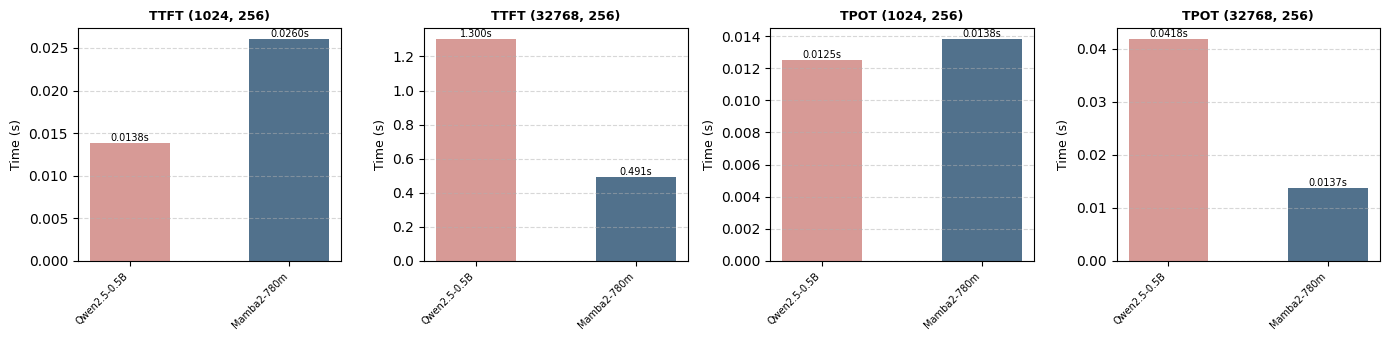

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 4 subplots in a 1x4 horizontal layout
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

models = ['Qwen2.5-0.5B', 'Mamba2-780m']
colors = ['#CD817C', '#254E70']
bar_width = 0.5

# Plot 1: TTFT for scenario (1024, 256)
ax = axes[0]
x = np.arange(len(models))
values = [qwen_ttft[0], mamba_ttft[0]]
bars = ax.bar(x, values, bar_width, color=colors, alpha=0.8)
ax.set_ylabel('Time (s)', fontsize=9)
ax.set_title('TTFT (1024, 256)', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=7, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}s', 
            ha='center', va='bottom', fontsize=7)

# Plot 2: TTFT for scenario (32768, 256)
ax = axes[1]
values = [qwen_ttft[1], mamba_ttft[1]]
bars = ax.bar(x, values, bar_width, color=colors, alpha=0.8)
ax.set_ylabel('Time (s)', fontsize=9)
ax.set_title('TTFT (32768, 256)', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=7, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}s', 
            ha='center', va='bottom', fontsize=7)

# Plot 3: TPOT for scenario (1024, 256)
ax = axes[2]
values = [qwen_tpot[0], mamba_tpot[0]]
bars = ax.bar(x, values, bar_width, color=colors, alpha=0.8)
ax.set_ylabel('Time (s)', fontsize=9)
ax.set_title('TPOT (1024, 256)', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=7, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}s', 
            ha='center', va='bottom', fontsize=7)

# Plot 4: TPOT for scenario (32768, 256)
ax = axes[3]
values = [qwen_tpot[1], mamba_tpot[1]]
bars = ax.bar(x, values, bar_width, color=colors, alpha=0.8)
ax.set_ylabel('Time (s)', fontsize=9)
ax.set_title('TPOT (32768, 256)', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=7, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}s', 
            ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

## Publication Figure

Clean version of the same plot — axis ticks and labels removed for use as a paper figure. The output is saved to `{prof_dir}/intro_ttft_tpot.png` at 300 DPI.

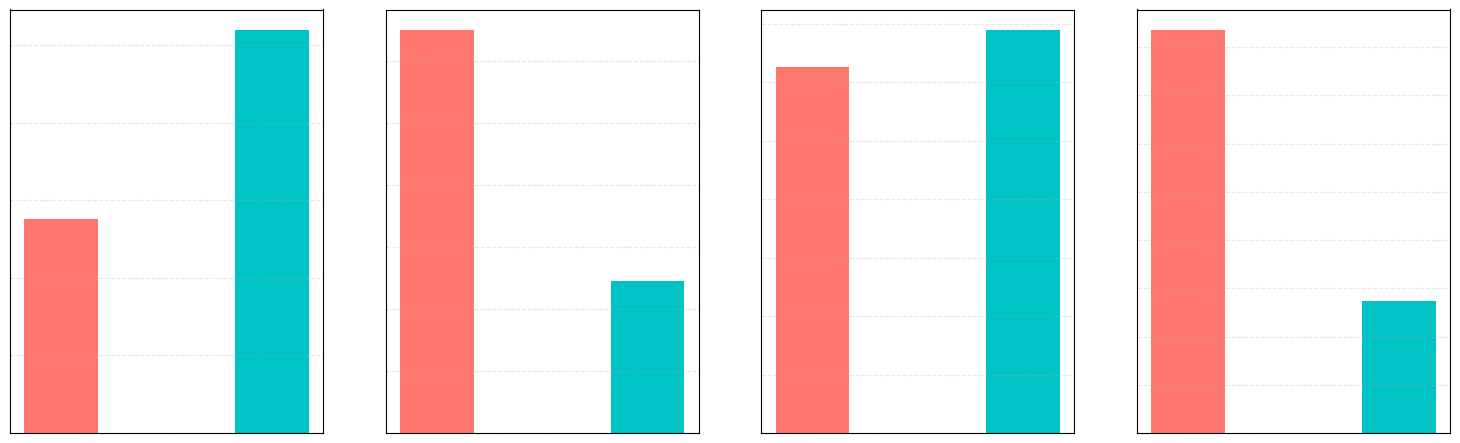

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 4 subplots in a 1x4 horizontal layout with more spacing
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))

models = ['Qwen2.5-0.5B', 'Mamba2-780m']
colors = ['#FF776E', '#00C3C5']
bar_width = 0.35

# Plot 1: TTFT for scenario (1024, 64)
ax = axes[0]
x = np.arange(len(models))
values = [qwen_ttft[0], mamba_ttft[0]]
bars = ax.bar(x, values, bar_width, color=colors)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Plot 2: TTFT for scenario (32768, 64)
ax = axes[1]
values = [qwen_ttft[1], mamba_ttft[1]]
bars = ax.bar(x, values, bar_width, color=colors)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Plot 3: TPOT for scenario (1024, 64)
ax = axes[2]
values = [qwen_tpot[0], mamba_tpot[0]]
bars = ax.bar(x, values, bar_width, color=colors)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Plot 4: TPOT for scenario (32768, 64)
ax = axes[3]
values = [qwen_tpot[1], mamba_tpot[1]]
bars = ax.bar(x, values, bar_width, color=colors)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Increase spacing between subplots
plt.subplots_adjust(left=0.05, right=0.95, wspace=0.2, hspace=0.5)
plt.savefig(f"{prof_dir}/intro_ttft_tpot.png", bbox_inches="tight", dpi=300)
plt.show()